- [<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> Epsilon-Greedy: Análisis de Exploración](https://colab.research.google.com/github/AlbertoLopezCorbalan/eml-albertolopezc/blob/main/k_brazos/epsilon-greedy-exploration.ipynb)  

# Estudio comparativo de algoritmos en un problema de k-armed bandit

El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Alberto López Corbalán
    Email: alberto.lopezc@um.es
    Date: 2026/06/05



## Preparación del entorno


In [1]:
#@title Copiar el repositorio.

import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone https://github.com/AlbertoLopezCorbalan/eml-albertolopezc
    %cd eml-albertolopezc/k_brazos

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


In [2]:
#@title Importamos todas las clases y funciones

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedyExploration
from arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regret_accumulated = np.zeros((len(algorithms), steps))  # Matriz para almacenar el rechazo acumulado

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    # Información para la función plot_arm_statistics
    arm_selections = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar los brazos elegidos
    arm_rewards_sum = np.zeros((len(algorithms), len(bandit.arms))) # Matriz para almacenar las recompensas de cada brazos

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        regret_accumulated_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.

                arm_selections[idx, chosen_arm] += 1 # Acumular el numero de selecciones de un brazo
                arm_rewards_sum[idx, chosen_arm] += reward # Acumular las recompensas de ese brazo

                regret_accumulated_per_algo[idx] += current_bandit.pull_arm(optimal_arm) - reward # Se calcula la perdida
                regret_accumulated[idx, step] += regret_accumulated_per_algo[idx]  # Acumulamos la perdida por no elegir el brazo correcto
                
                if optimal_arm == chosen_arm:
                    optimal_selections[idx, step] += 1 # Si el brazo elegido se corresponda con el brazo óptimo

    
    rewards /= runs
    regret_accumulated /= runs
    optimal_selections = (optimal_selections / runs) * 100 # Calcula el porcentaje de selecciones óptimas

    # Calculamos el promedio de las ganancias de cada brazo
    avg_arm_rewards = np.divide(arm_rewards_sum, arm_selections, out=np.zeros_like(arm_rewards_sum), where=arm_selections > 0)

    return rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections

## Configuración del experimento
Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedyExploration(k=k, epsilon=0), EpsilonGreedyExploration(k=k, epsilon=0.01), EpsilonGreedyExploration(k=k, epsilon=0.1)]

## Ejecución del experimento Normal
Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1.

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


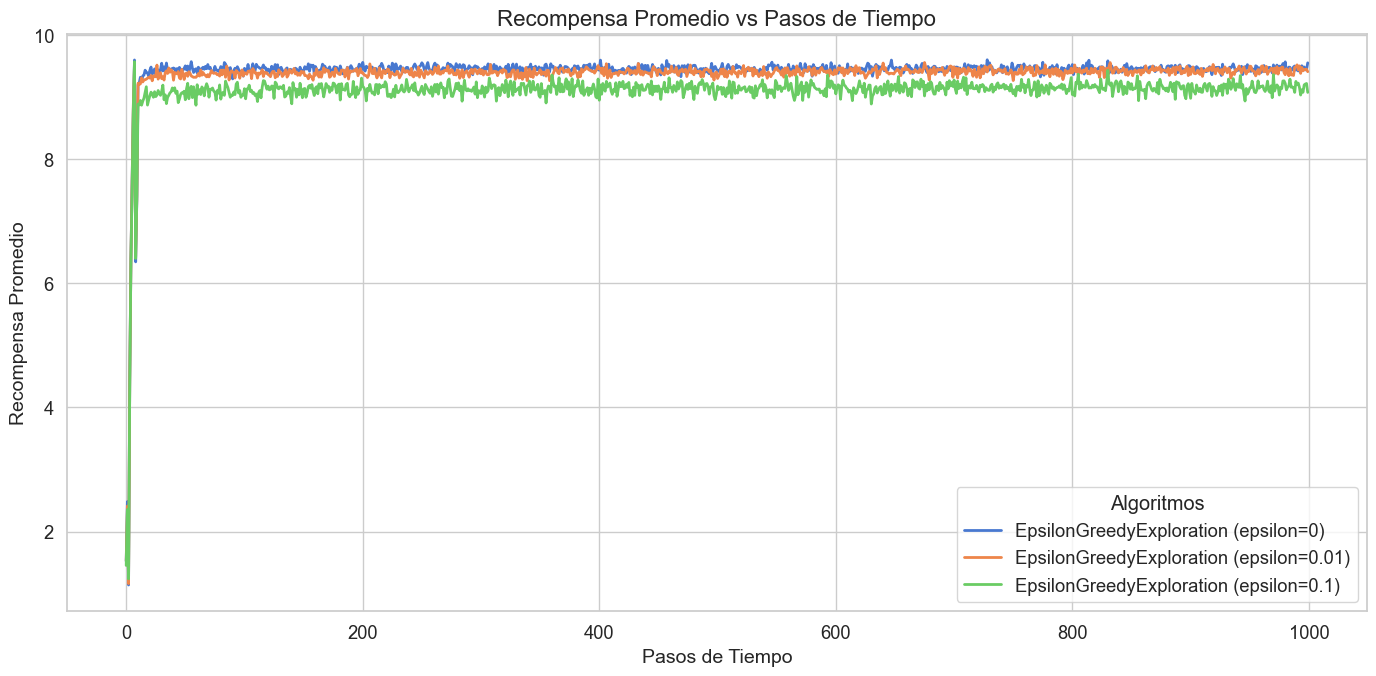

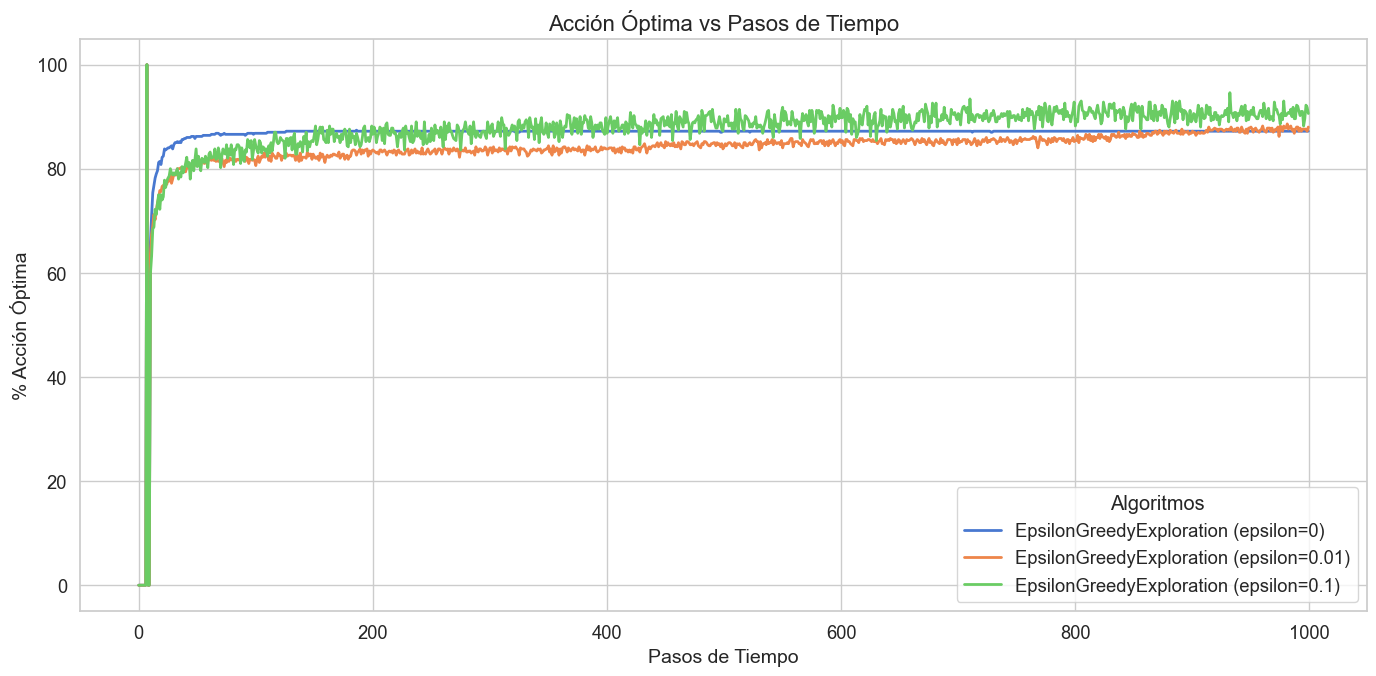

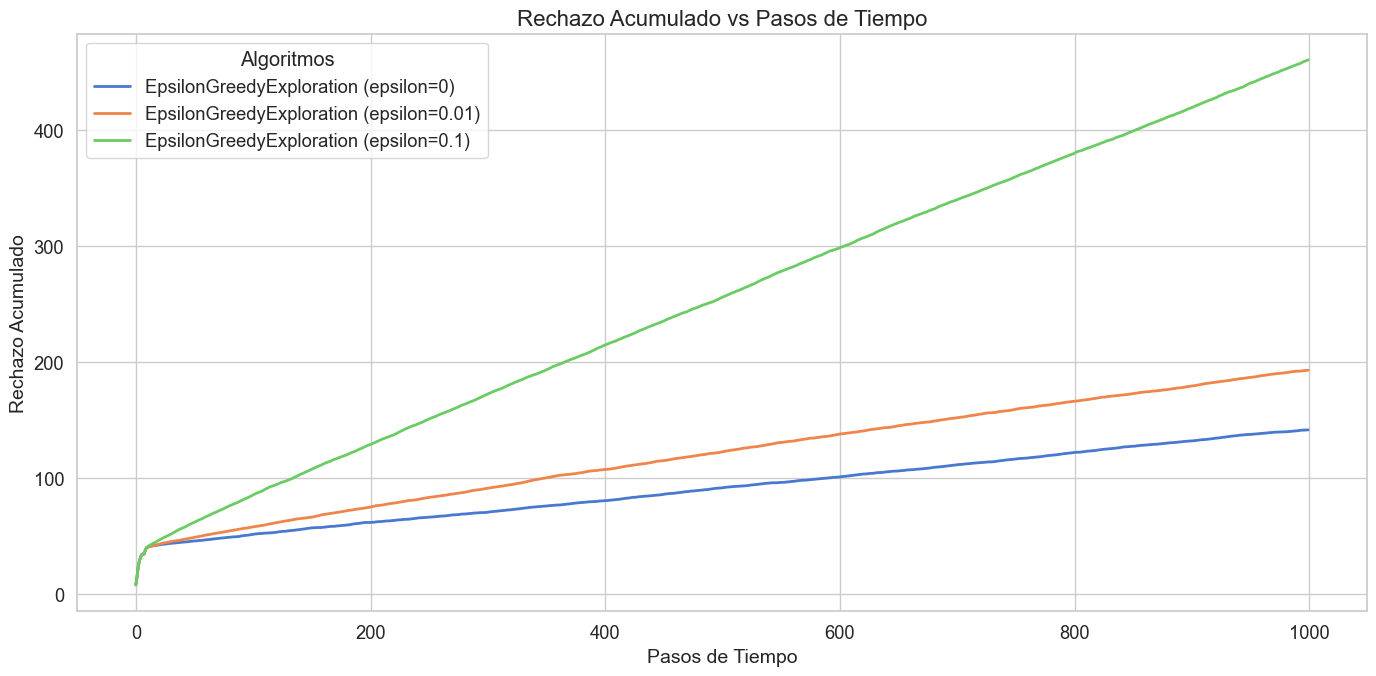

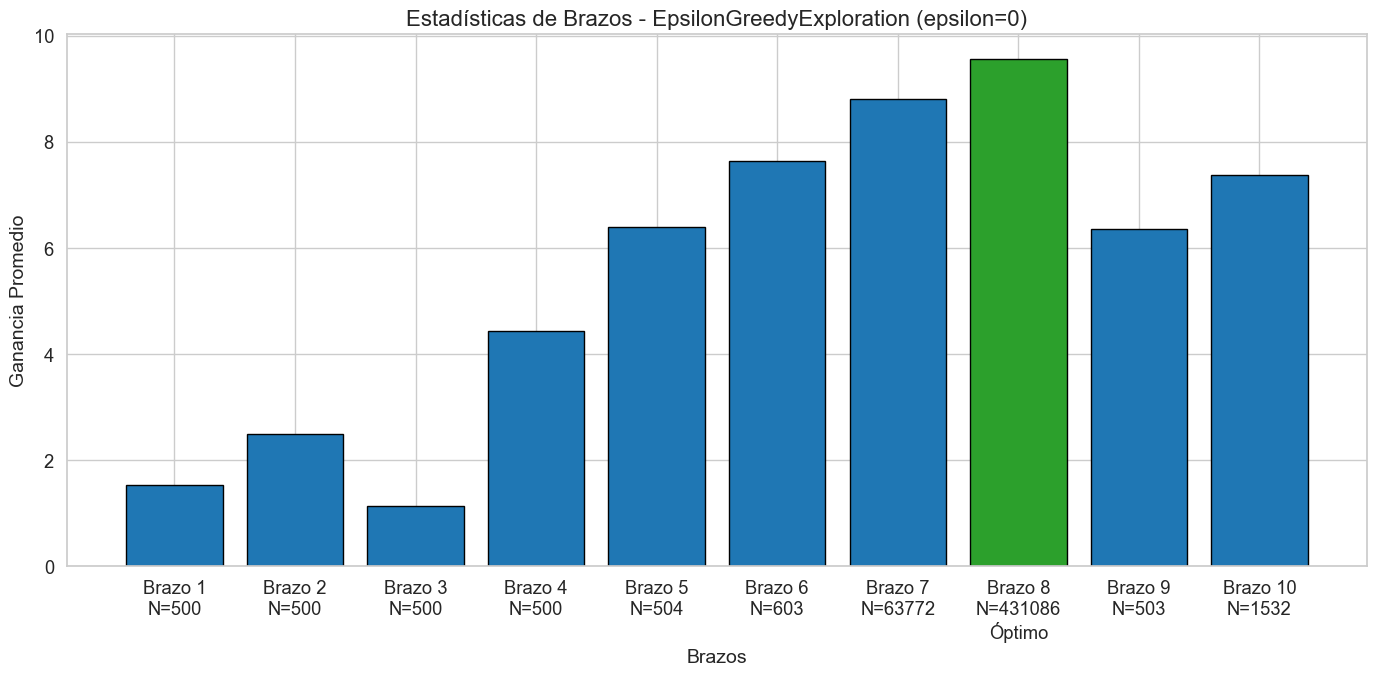

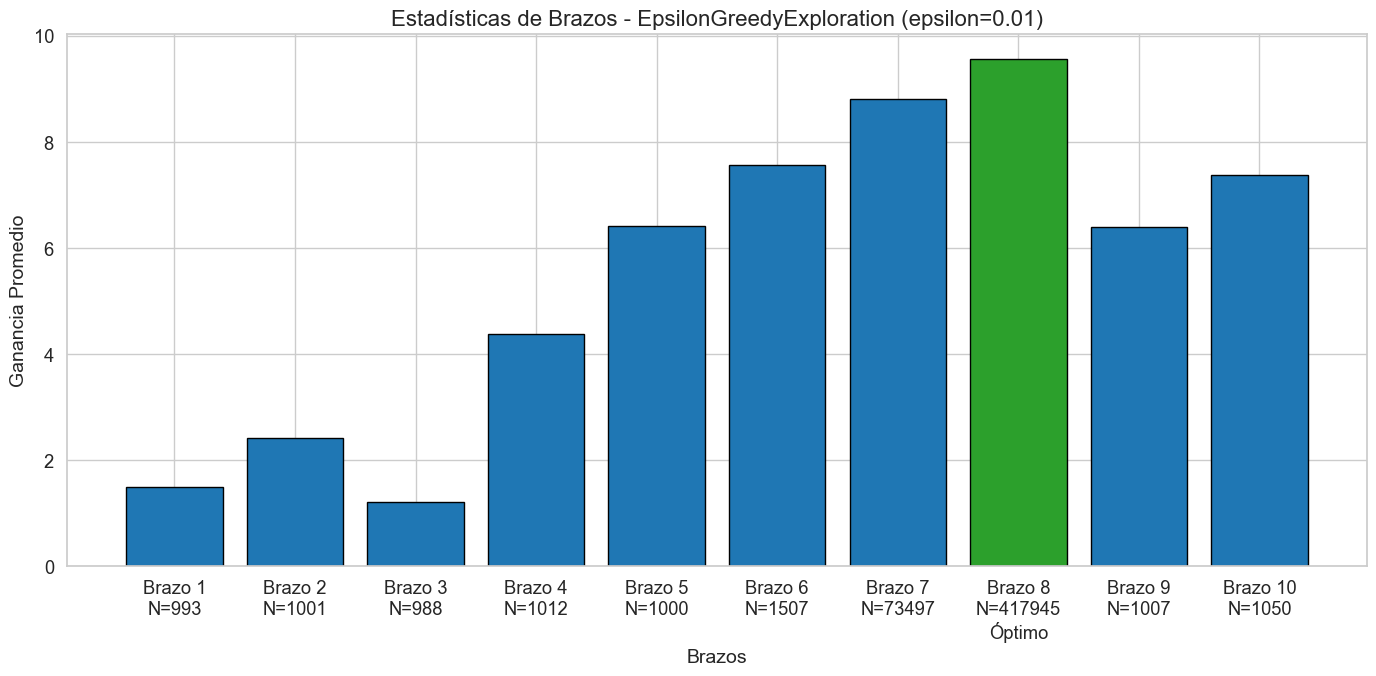

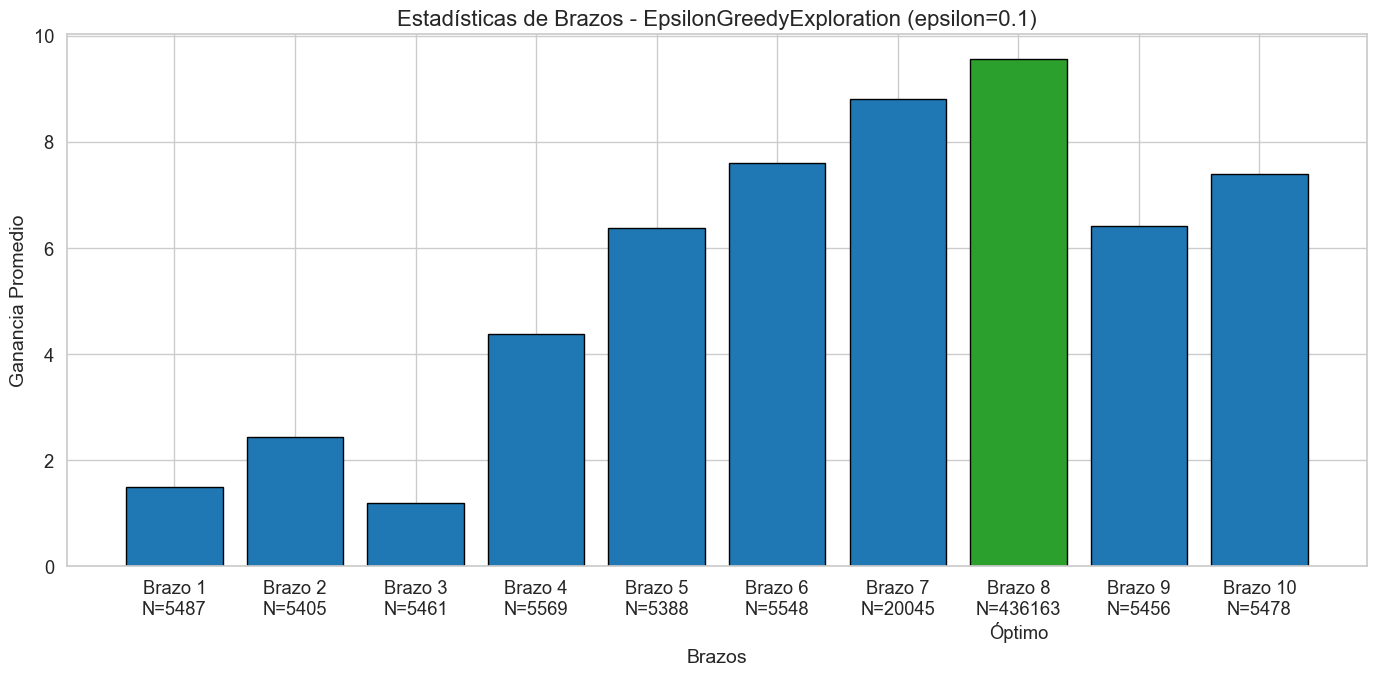

In [5]:
# Creación del bandit
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_normal, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

## Ejecución del experimento Binomial

Bandit with 10 arms: ArmBinomial(n=10, p=0.51), ArmBinomial(n=10, p=0.62), ArmBinomial(n=10, p=0.85), ArmBinomial(n=10, p=0.18), ArmBinomial(n=10, p=0.16), ArmBinomial(n=10, p=0.63), ArmBinomial(n=10, p=0.4), ArmBinomial(n=10, p=0.76), ArmBinomial(n=10, p=0.14), ArmBinomial(n=10, p=0.7)
Optimal arm: 3 with expected reward=8.5


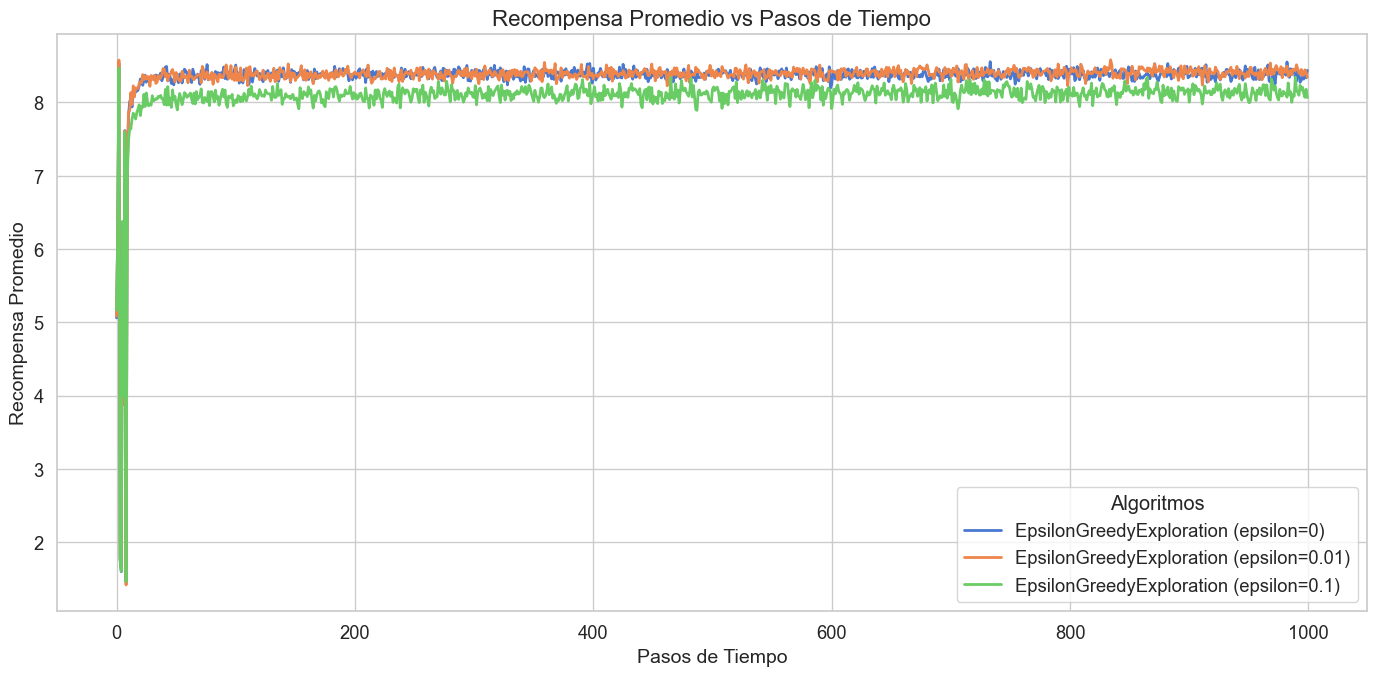

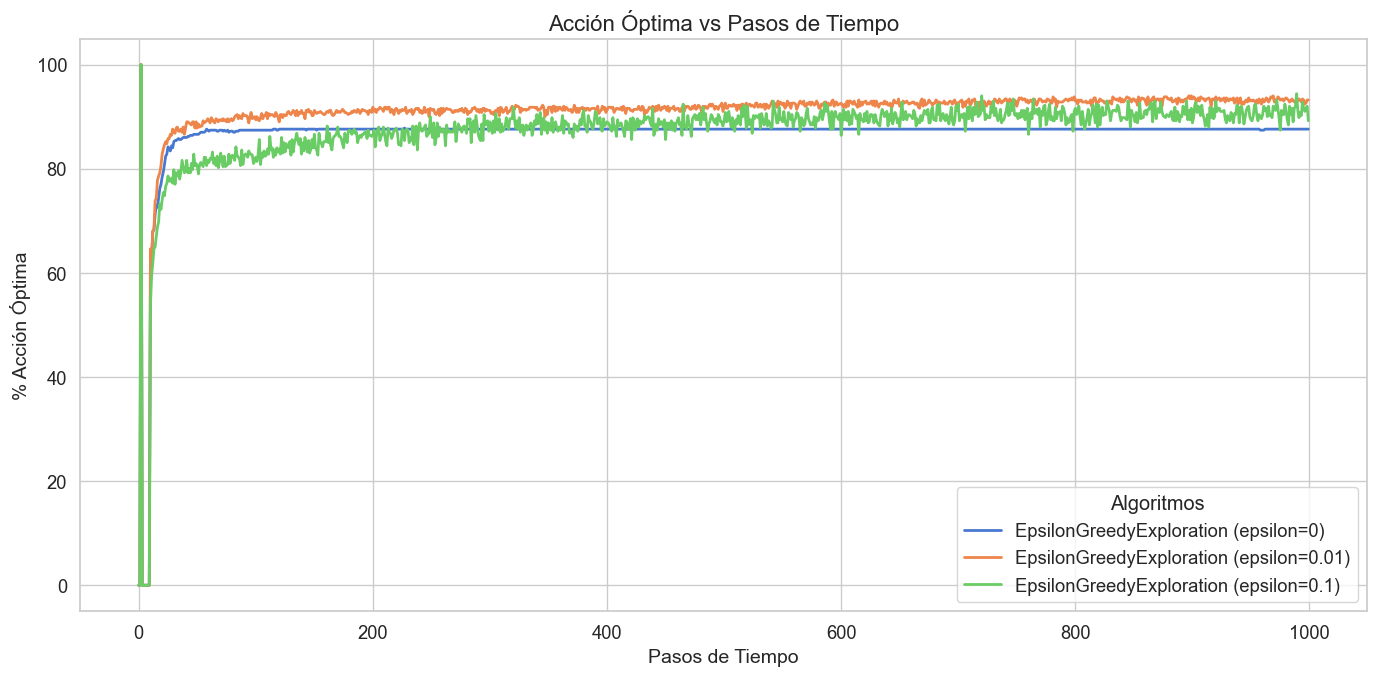

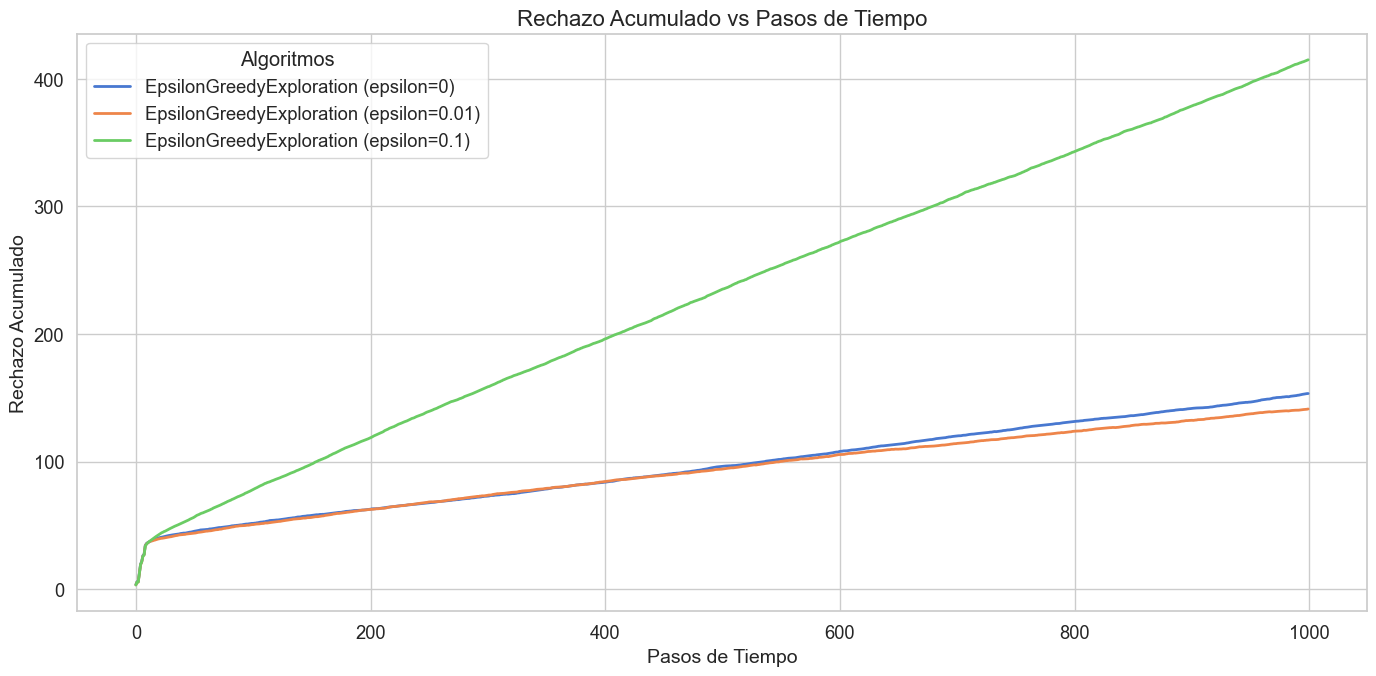

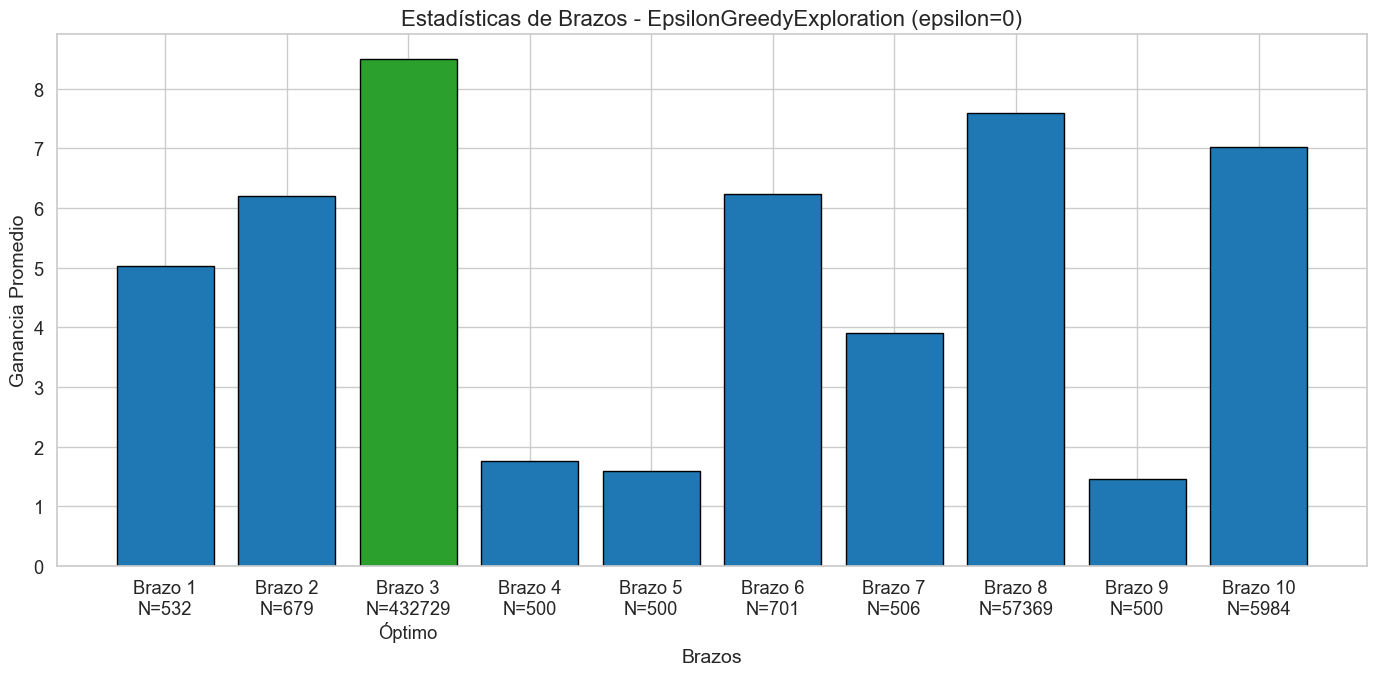

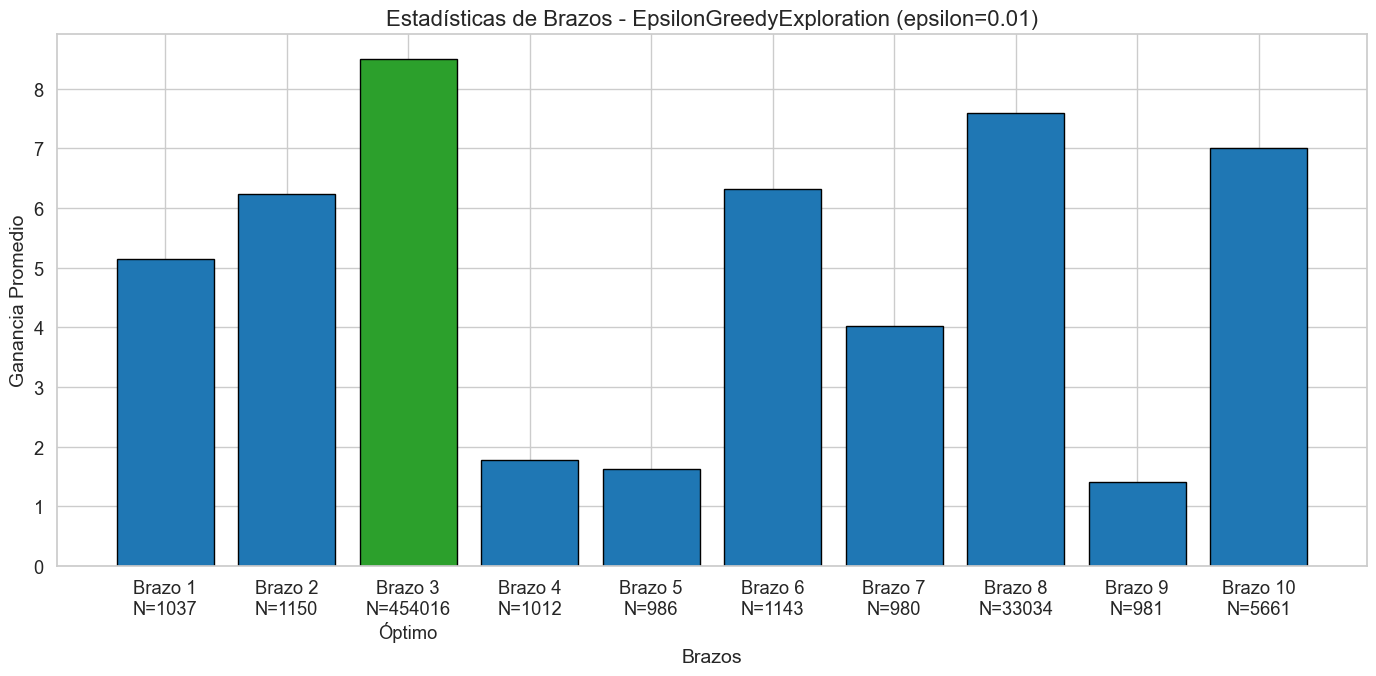

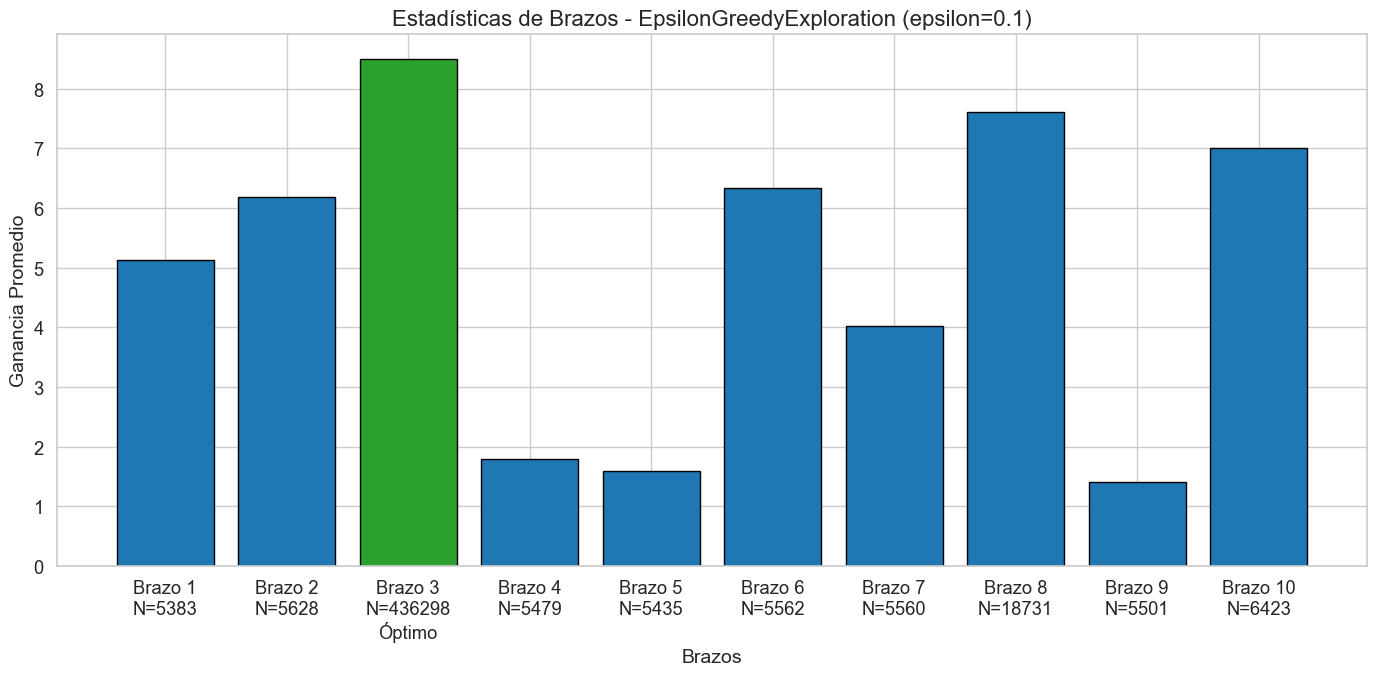

In [6]:
# Creación del bandit
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_binomial)

optimal_arm = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_binomial, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

## Ejecución del experimento Bernoulli

Bandit with 10 arms: ArmBinomial(n=1, p=0.59), ArmBinomial(n=1, p=0.13), ArmBinomial(n=1, p=0.49), ArmBinomial(n=1, p=0.47), ArmBinomial(n=1, p=0.7), ArmBinomial(n=1, p=0.42), ArmBinomial(n=1, p=0.15), ArmBinomial(n=1, p=0.14), ArmBinomial(n=1, p=0.65), ArmBinomial(n=1, p=0.53)
Optimal arm: 5 with expected reward=0.7


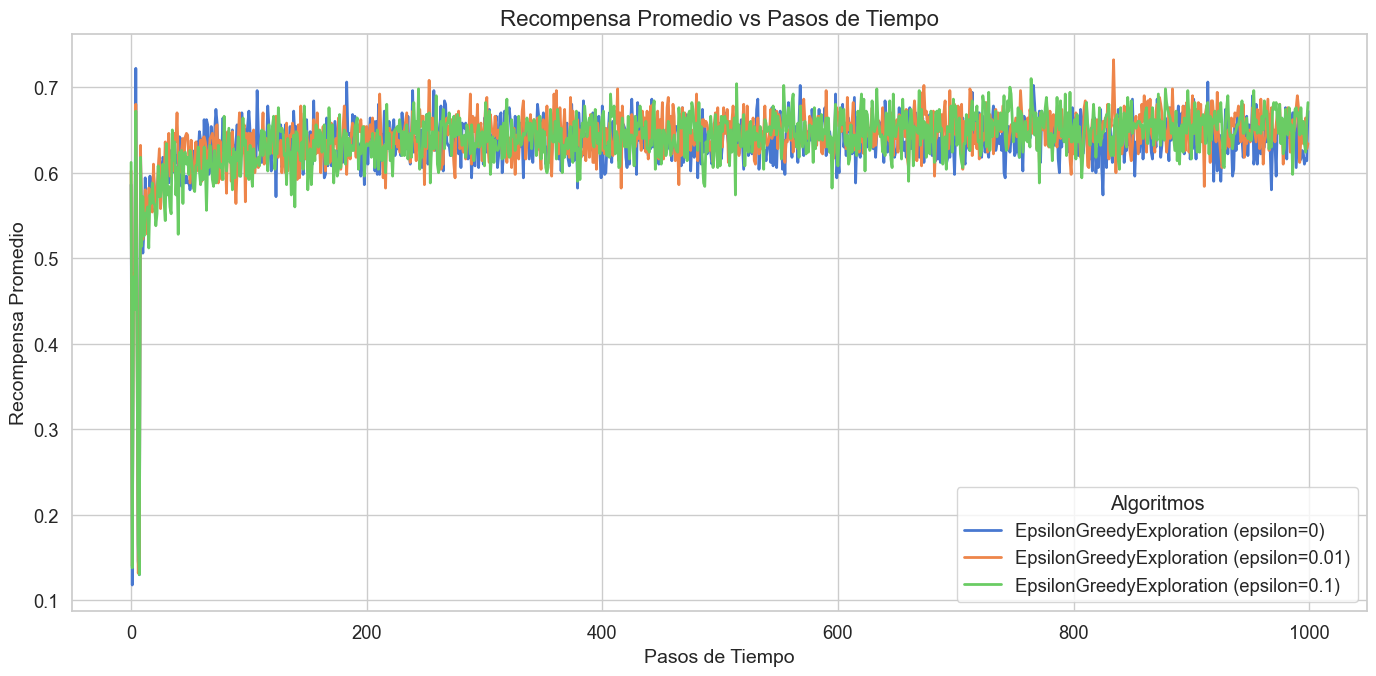

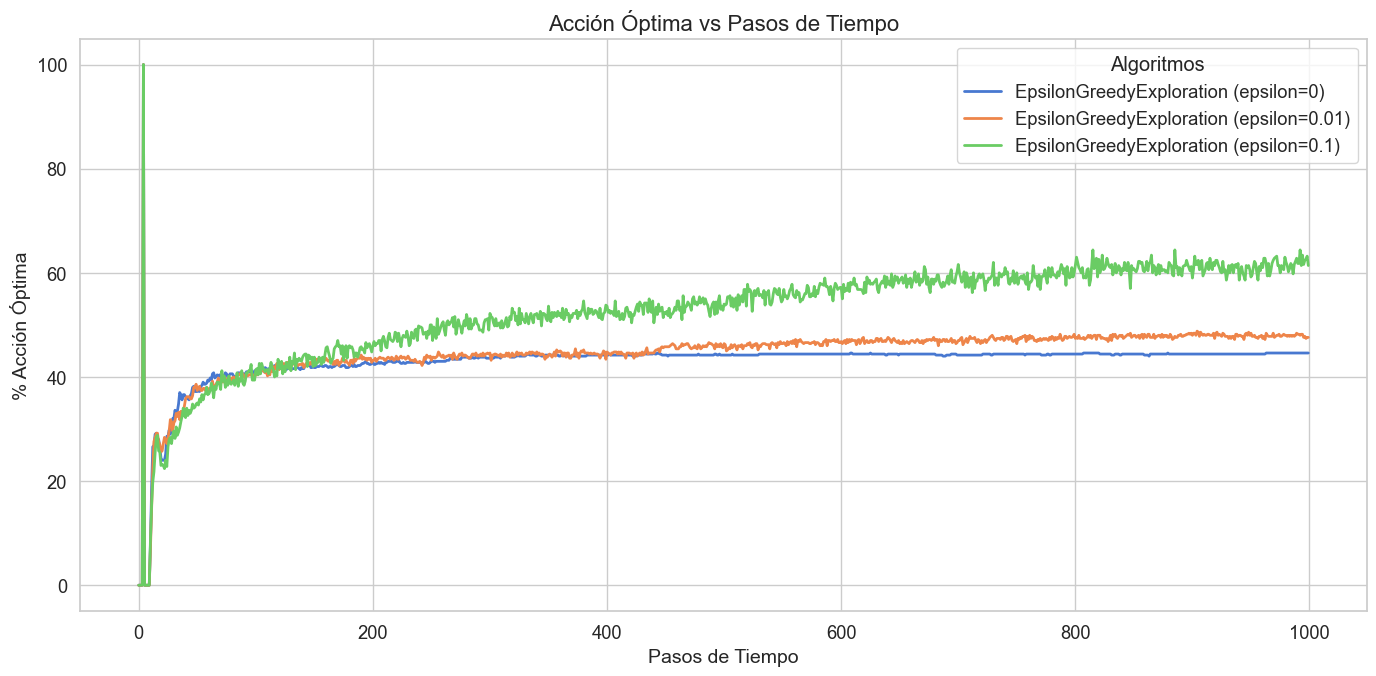

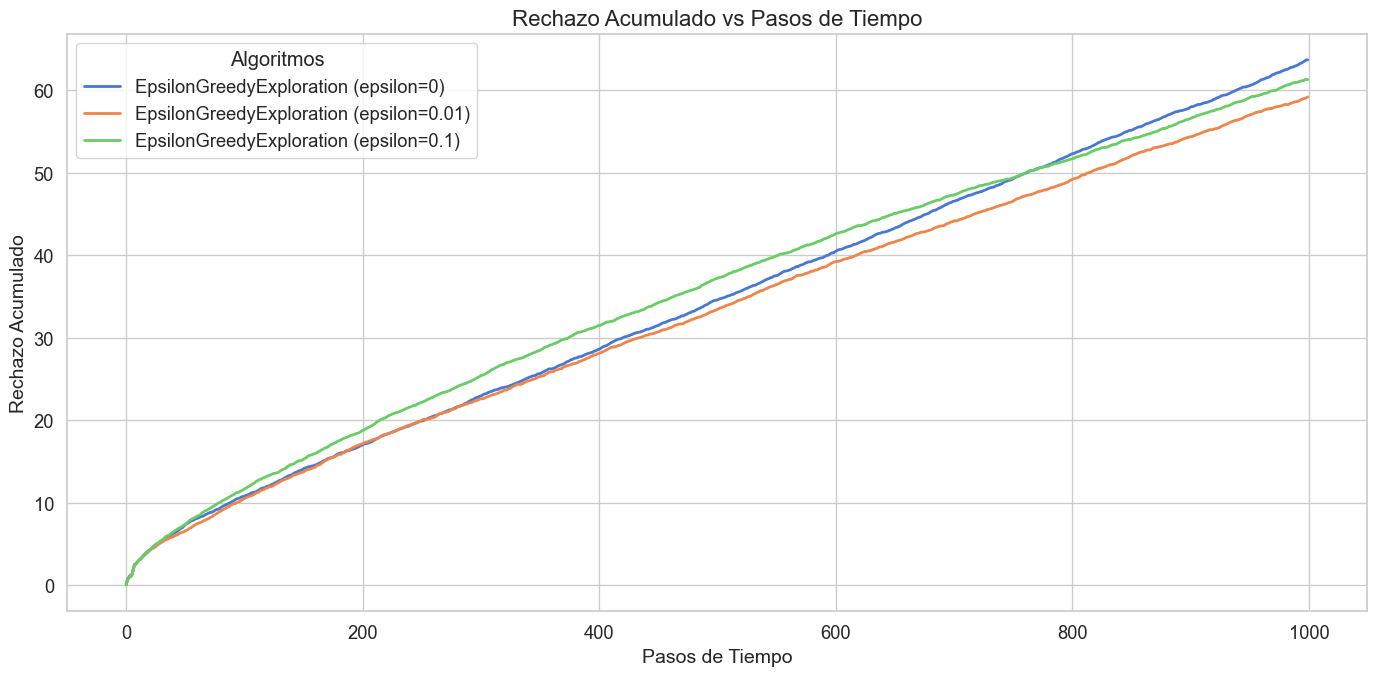

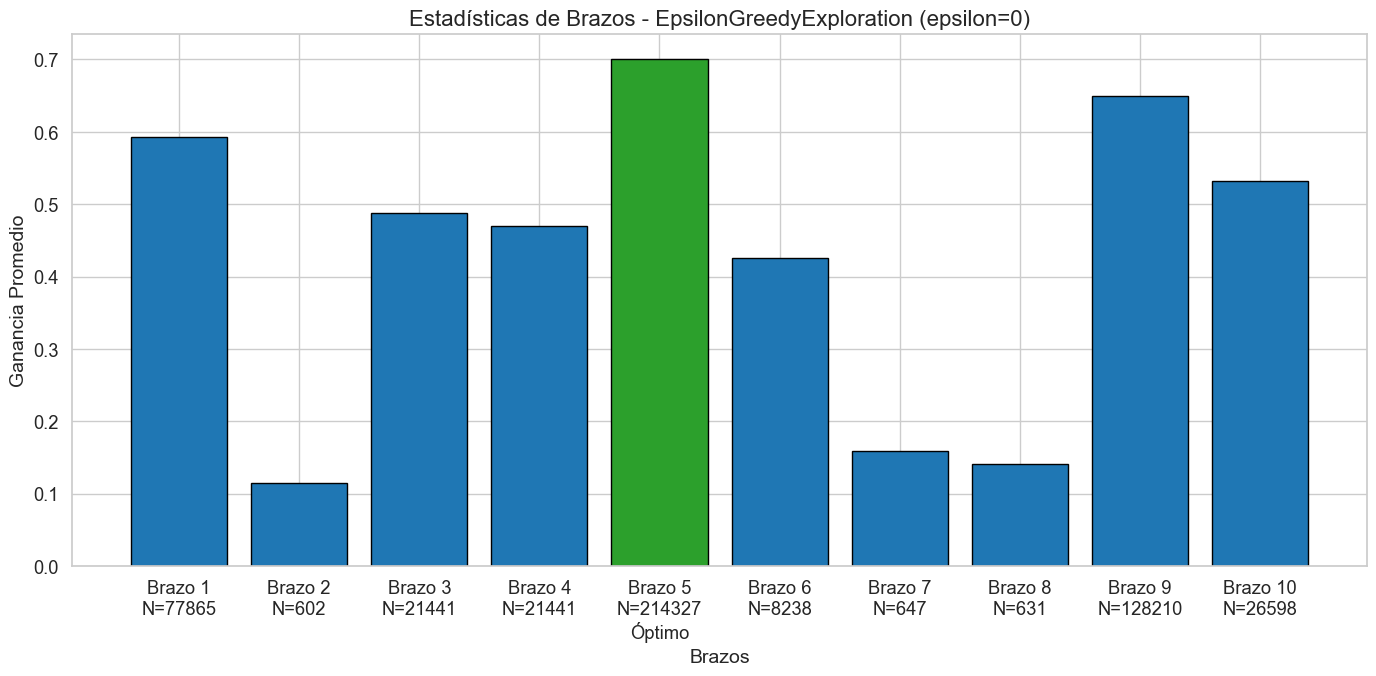

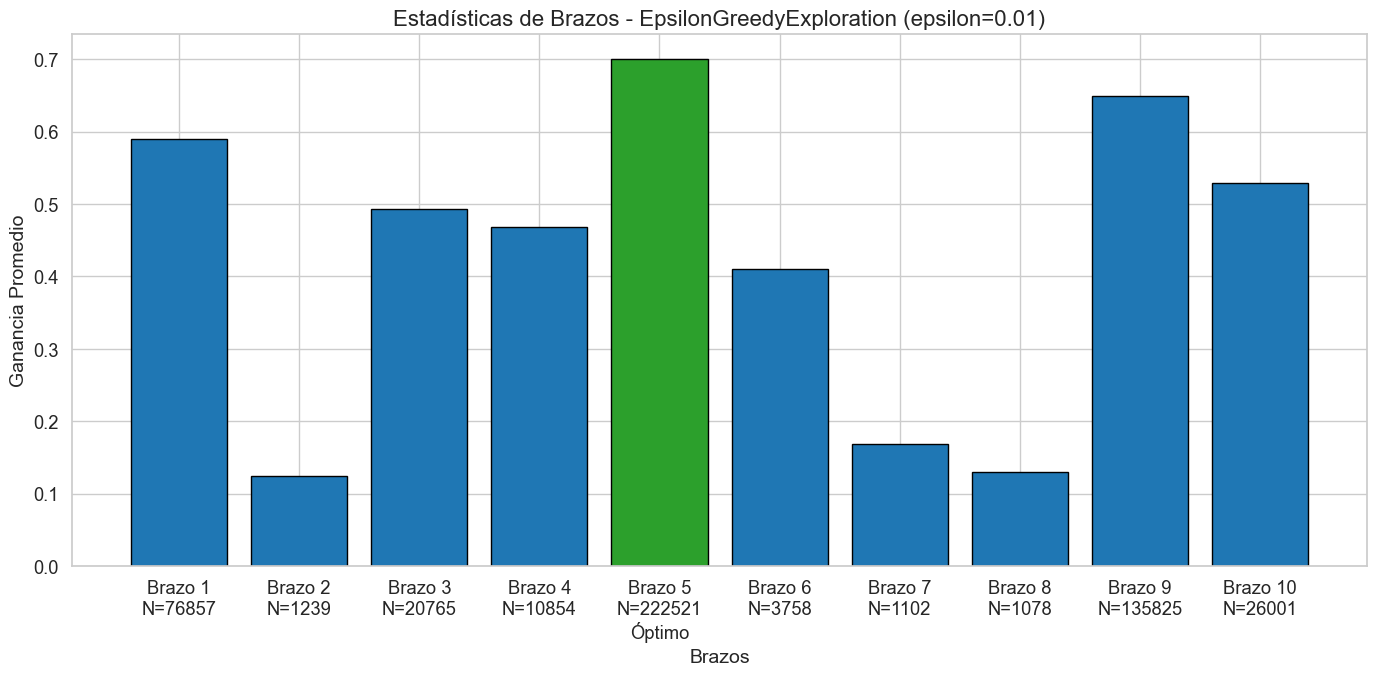

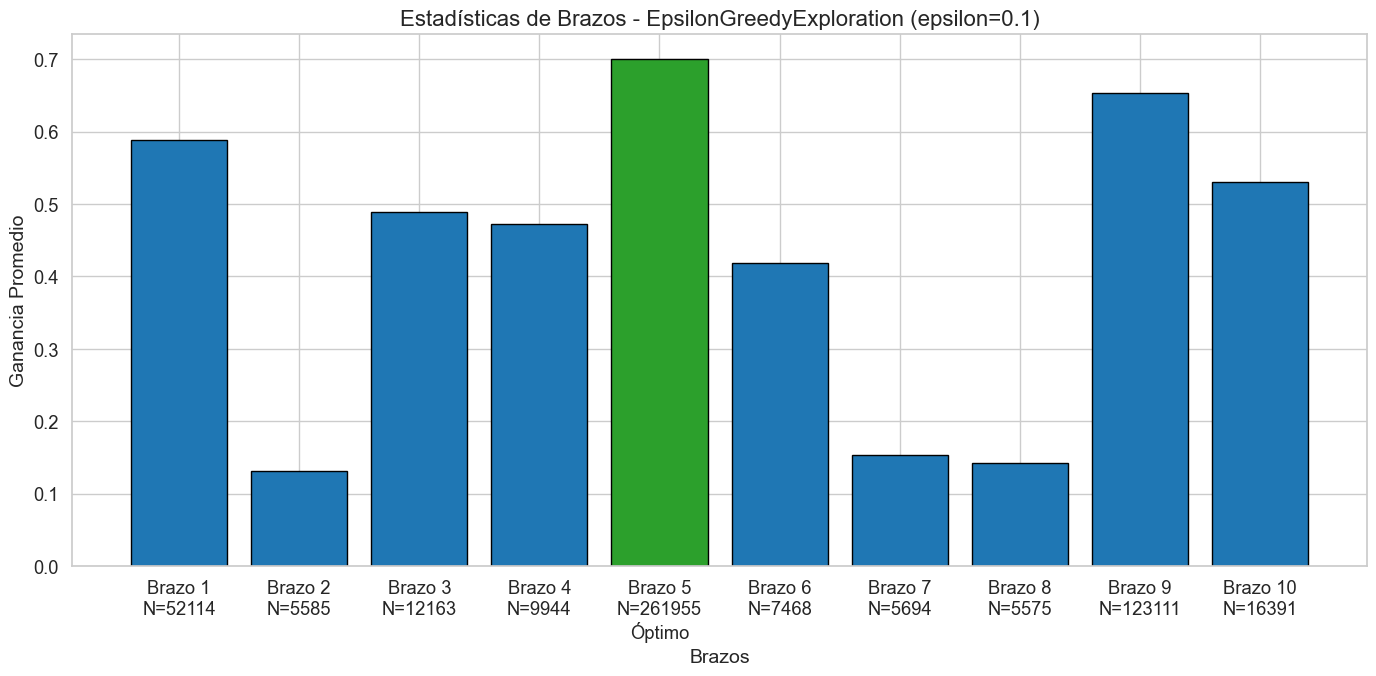

In [7]:
# Creación del bandit
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit_bernoulli)

optimal_arm = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm)}")

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, avg_arm_rewards, arm_selections = run_experiment(bandit_bernoulli, algorithms, steps, runs)

# Mostramos los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regret_accumulated, algorithms)
plot_arm_statistics(avg_arm_rewards, arm_selections, optimal_arm, algorithms)

Se muestran unos gráficos de líneas donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio/acción óptima/rechazo acumulado** por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Crecimiento de la recompensa promedio:**
   - La línea **verde (ε=0.1)** alcanza rápidamente el mejor de los resultados, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también obtiene un buen resultado, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** no obtiene buenos resultados porque no explora nuevas opciones.

---





## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado solo en el estudio del algoritmo epsilon-greedy, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráfica generada:

#### **1. Exploración vs Explotación**
El algoritmo **ε-Greedy** equilibra la exploración y la explotación:
- **Explotación (ε=0)**: Siempre elige la mejor opción conocida, pero si inicialmente se selecciona un brazo subóptimo, nunca descubrirá otras opciones más rentables.
- **Exploración (ε>0)**: Introduce aleatoriedad en la selección de acciones para descubrir nuevas opciones potencialmente mejores.

El gráfico confirma este comportamiento:
- **ε=0.1 (verde)** obtiene la mejor recompensa porque explora lo suficiente como para encontrar rápidamente el mejor brazo.
- **ε=0.01 (naranja)** explora menos, por lo que tiene peor rendimiento.
- **ε=0 (azul)** no explora en absoluto y obtiene los peores resultados.

#### **2. Convergencia de los algoritmos**
Los algoritmos con mayor exploración (ε=0.1) alcanzan una recompensa alta más rápido. Esto se debe a que:
- Al principio, el algoritmo **no tiene información suficiente** sobre cuál es el mejor brazo.
- Con el tiempo, al realizar exploraciones, descubre cuál es el mejor brazo y empieza a explotarlo más.
- Un **balance entre exploración y explotación** es clave para maximizar la recompensa a largo plazo.


#### **3. Aplicaciones y conclusiones**
- En problemas de toma de decisiones **(ejemplo: recomendaciones, optimización de anuncios, medicina personalizada)**, una estrategia de exploración moderada como **ε=0.1** es más efectiva para encontrar la mejor opción rápidamente.
- **La falta de exploración (ε=0)** lleva a un desempeño deficiente, ya que el agente puede quedarse atrapado en una elección subóptima.

En conclusión, **el gráfico muestra cómo un nivel adecuado de exploración mejora significativamente el rendimiento del algoritmo en un entorno de aprendizaje por refuerzo**. 🚀